In [1]:
import warnings
warnings.filterwarnings("ignore")

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 17
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["legend.fontsize"] = 11

In [2]:
df = pd.read_csv("/content/ushape.csv")

display(df.head())

,X,Y,class
0,0.0316,0.9870,0.0
1,2.1200,-0.0462,1.0
2,0.8820,-0.0758,0.0
3,-0.0551,-0.0373,1.0
4,0.8300,-0.5390,1.0


In [3]:
print("Shape:", df.shape)
print()
print(df.info())

Shape: (100, 3)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       100 non-null    float64
 1   Y       100 non-null    float64
 2   class   100 non-null    float64
dtypes: float64(3)
memory usage: 2.5 KB
None


In [4]:
display(df.isnull().sum().to_frame("Missing Values"))

,Missing Values
X,0
Y,0
class,0


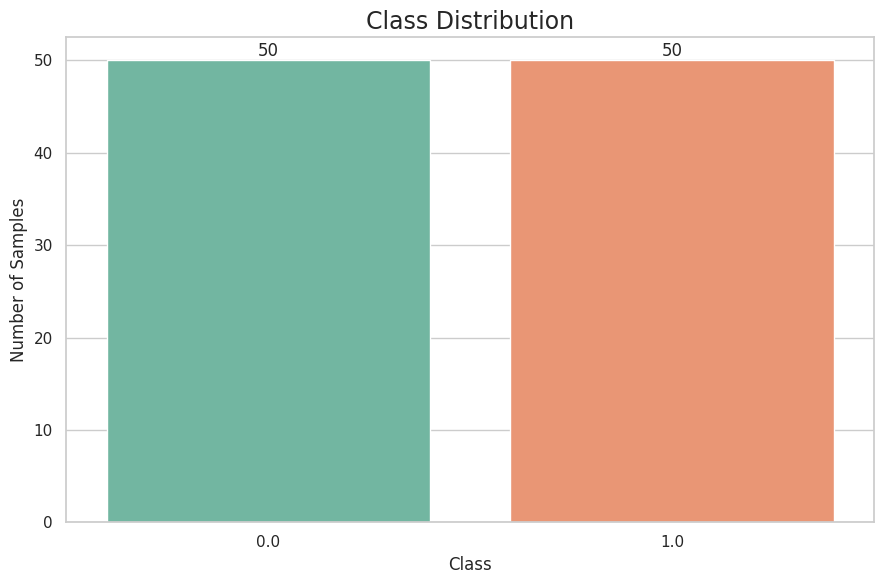

In [5]:
plt.figure(figsize=(9, 6))

ax = sns.countplot(
    data=df,
    x="class",
    hue="class",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.tight_layout()
plt.show()

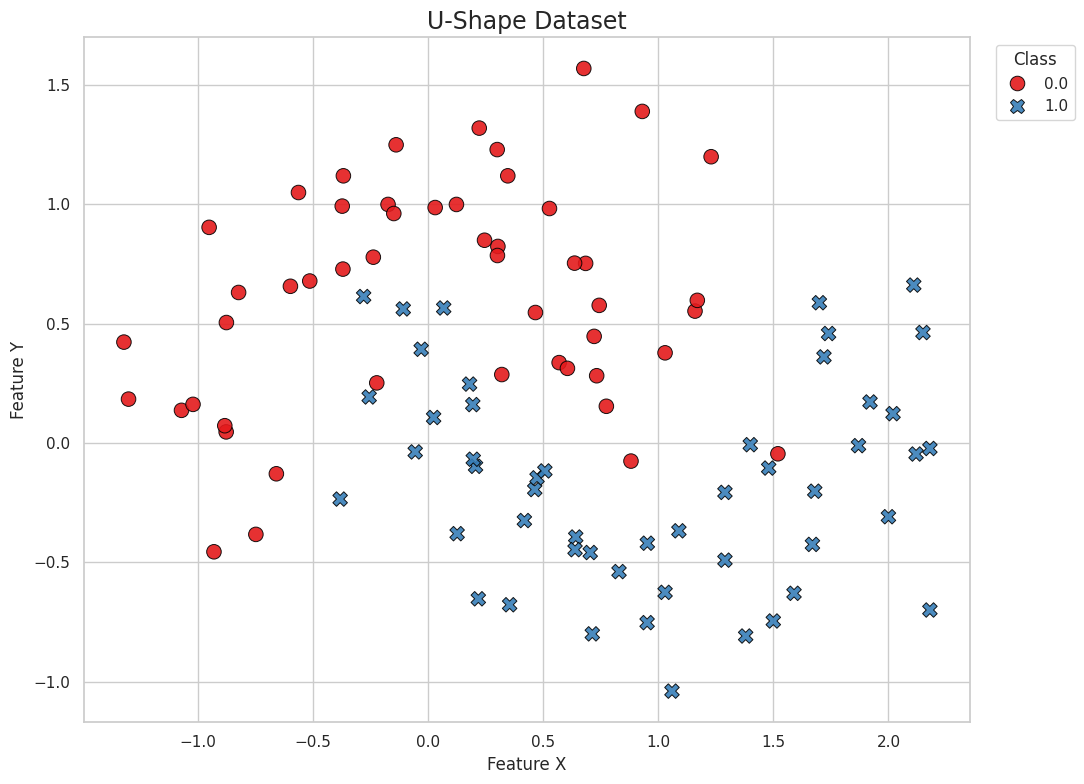

In [6]:
plt.figure(figsize=(11, 8))

sns.scatterplot(
    data=df,
    x="X",
    y="Y",
    hue="class",
    style="class",
    palette="Set1",
    s=110,
    alpha=0.9,
    edgecolor="black",
    linewidth=0.7
)

plt.title("U-Shape Dataset")
plt.xlabel("Feature X")
plt.ylabel("Feature Y")
plt.legend(
    title="Class",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [7]:
X = df[["X", "Y"]].values.astype(np.float32)
y = df["class"].values.astype(np.float32)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (100, 2)
y Shape: (100,)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 80
Testing Samples: 20


In [9]:
zero_sigmoid_model = Sequential([
    Input(shape=(2,)),
    Dense(
        10,
        activation="sigmoid",
        kernel_initializer="zeros",
        bias_initializer="zeros"
    ),
    Dense(
        10,
        activation="sigmoid",
        kernel_initializer="zeros",
        bias_initializer="zeros"
    ),
    Dense(
        1,
        activation="sigmoid",
        kernel_initializer="zeros",
        bias_initializer="zeros"
    )
])

zero_sigmoid_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [10]:
zero_sigmoid_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
for i, weight in enumerate(zero_sigmoid_model.get_weights()):
    print("Parameter", i)
    print("Shape:", weight.shape)
    print("Min:", np.min(weight))
    print("Max:", np.max(weight))
    print("Mean:", np.mean(weight))
    print("Std:", np.std(weight))
    print()

Parameter 0
Shape: (2, 10)
Min: 0.0
Max: 0.0
Mean: 0.0
Std: 0.0

Parameter 1
Shape: (10,)
Min: 0.0
Max: 0.0
Mean: 0.0
Std: 0.0

Parameter 2
Shape: (10, 10)
Min: 0.0
Max: 0.0
Mean: 0.0
Std: 0.0

Parameter 3
Shape: (10,)
Min: 0.0
Max: 0.0
Mean: 0.0
Std: 0.0

Parameter 4
Shape: (10, 1)
Min: 0.0
Max: 0.0
Mean: 0.0
Std: 0.0

Parameter 5
Shape: (1,)
Min: 0.0
Max: 0.0
Mean: 0.0
Std: 0.0



In [12]:
zero_sigmoid_history = zero_sigmoid_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

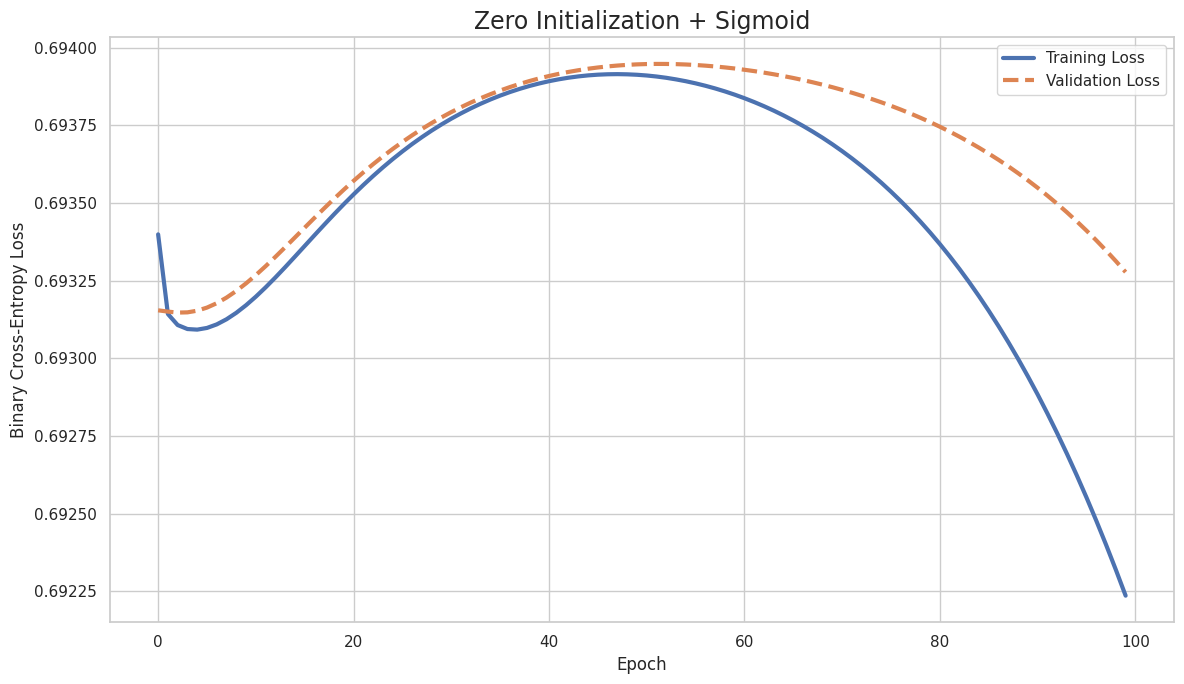

In [13]:
plt.figure(figsize=(12, 7))

plt.plot(
    zero_sigmoid_history.history["loss"],
    linewidth=3,
    label="Training Loss"
)

plt.plot(
    zero_sigmoid_history.history["val_loss"],
    linewidth=3,
    linestyle="--",
    label="Validation Loss"
)

plt.title("Zero Initialization + Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.tight_layout()
plt.show()

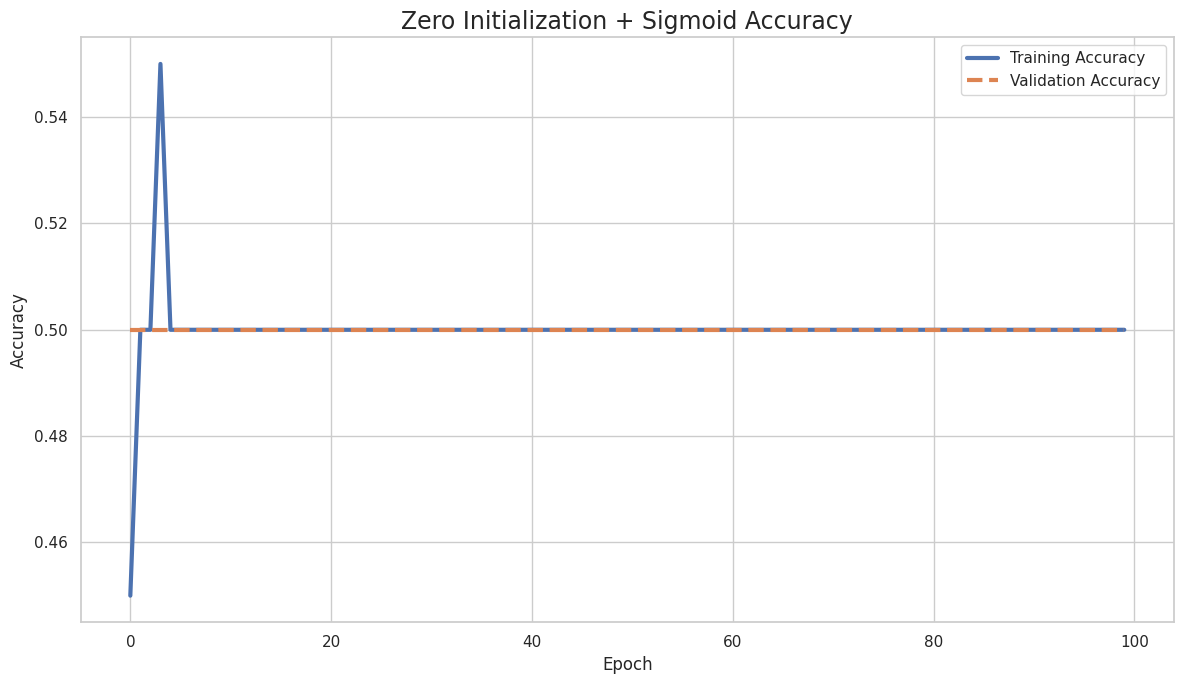

In [14]:
plt.figure(figsize=(12, 7))

plt.plot(
    zero_sigmoid_history.history["accuracy"],
    linewidth=3,
    label="Training Accuracy"
)

plt.plot(
    zero_sigmoid_history.history["val_accuracy"],
    linewidth=3,
    linestyle="--",
    label="Validation Accuracy"
)

plt.title("Zero Initialization + Sigmoid Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
zero_relu_model = Sequential([
    Input(shape=(2,)),
    Dense(
        10,
        activation="relu",
        kernel_initializer="zeros",
        bias_initializer="zeros"
    ),
    Dense(
        10,
        activation="relu",
        kernel_initializer="zeros",
        bias_initializer="zeros"
    ),
    Dense(
        1,
        activation="sigmoid"
    )
])

zero_relu_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [16]:
zero_relu_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [17]:
zero_relu_history = zero_relu_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

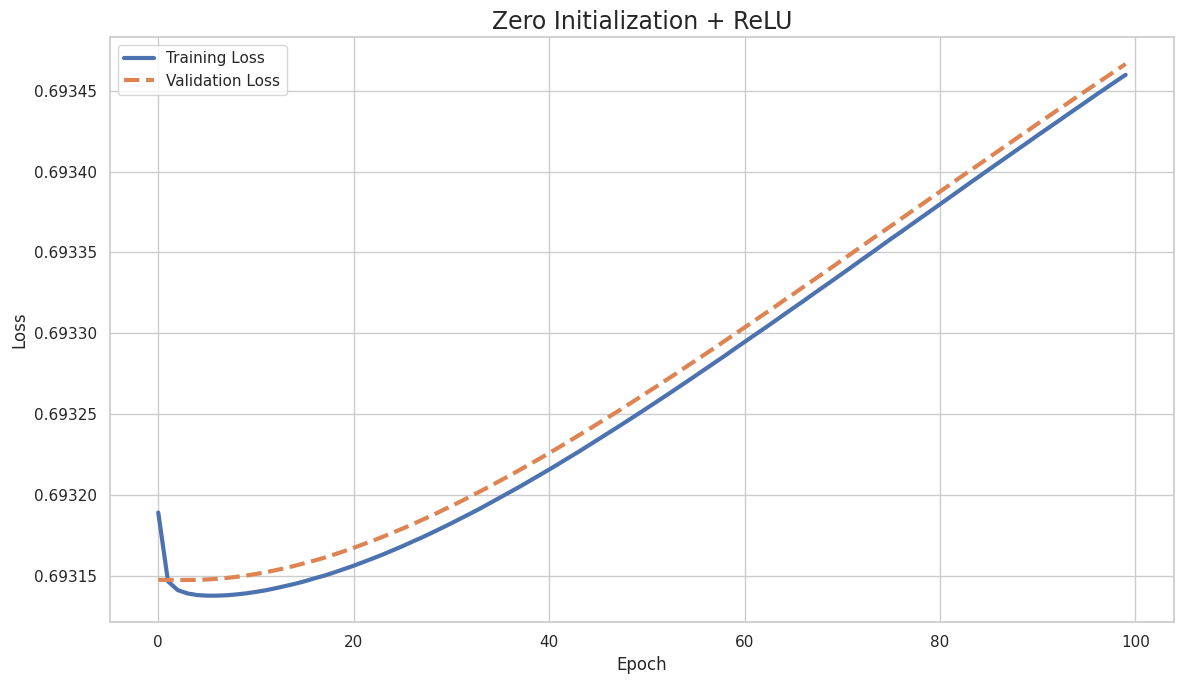

In [18]:
plt.figure(figsize=(12, 7))

plt.plot(
    zero_relu_history.history["loss"],
    linewidth=3,
    label="Training Loss"
)

plt.plot(
    zero_relu_history.history["val_loss"],
    linewidth=3,
    linestyle="--",
    label="Validation Loss"
)

plt.title("Zero Initialization + ReLU")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

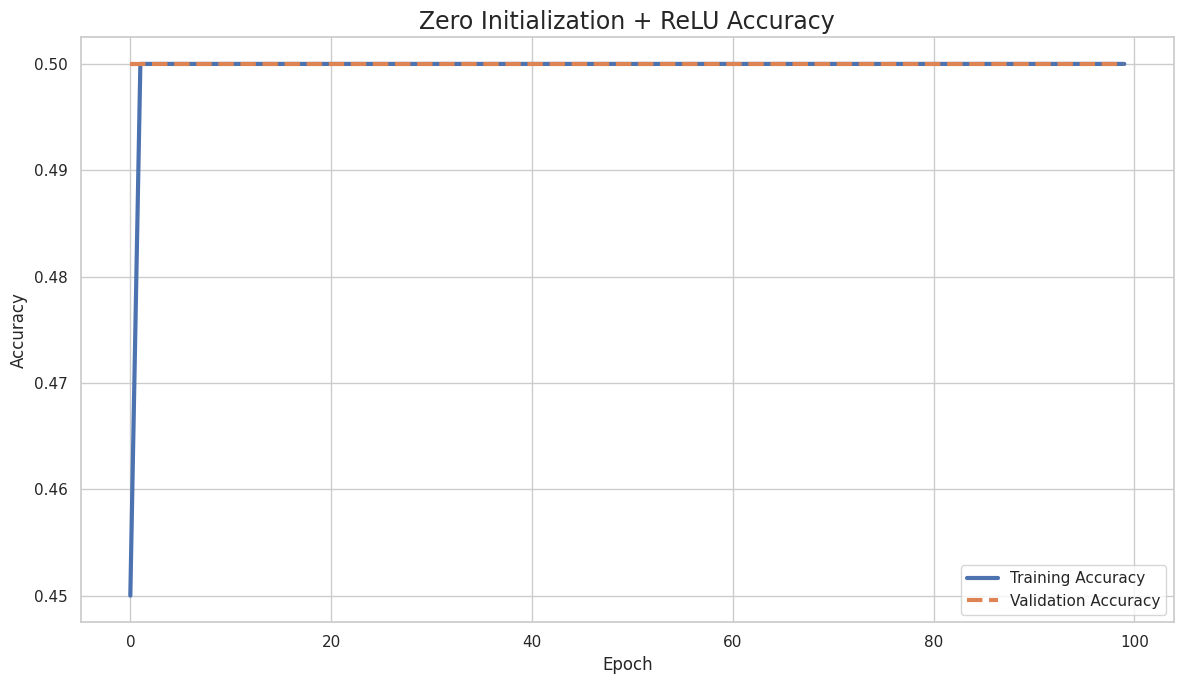

In [19]:
plt.figure(figsize=(12, 7))

plt.plot(
    zero_relu_history.history["accuracy"],
    linewidth=3,
    label="Training Accuracy"
)

plt.plot(
    zero_relu_history.history["val_accuracy"],
    linewidth=3,
    linestyle="--",
    label="Validation Accuracy"
)

plt.title("Zero Initialization + ReLU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
constant_initializer = keras.initializers.Constant(0.5)

constant_model = Sequential([
    Input(shape=(2,)),
    Dense(
        10,
        activation="sigmoid",
        kernel_initializer=constant_initializer,
        bias_initializer=constant_initializer
    ),
    Dense(
        10,
        activation="sigmoid",
        kernel_initializer=constant_initializer,
        bias_initializer=constant_initializer
    ),
    Dense(
        1,
        activation="sigmoid",
        kernel_initializer=constant_initializer,
        bias_initializer=constant_initializer
    )
])

constant_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
constant_history = constant_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

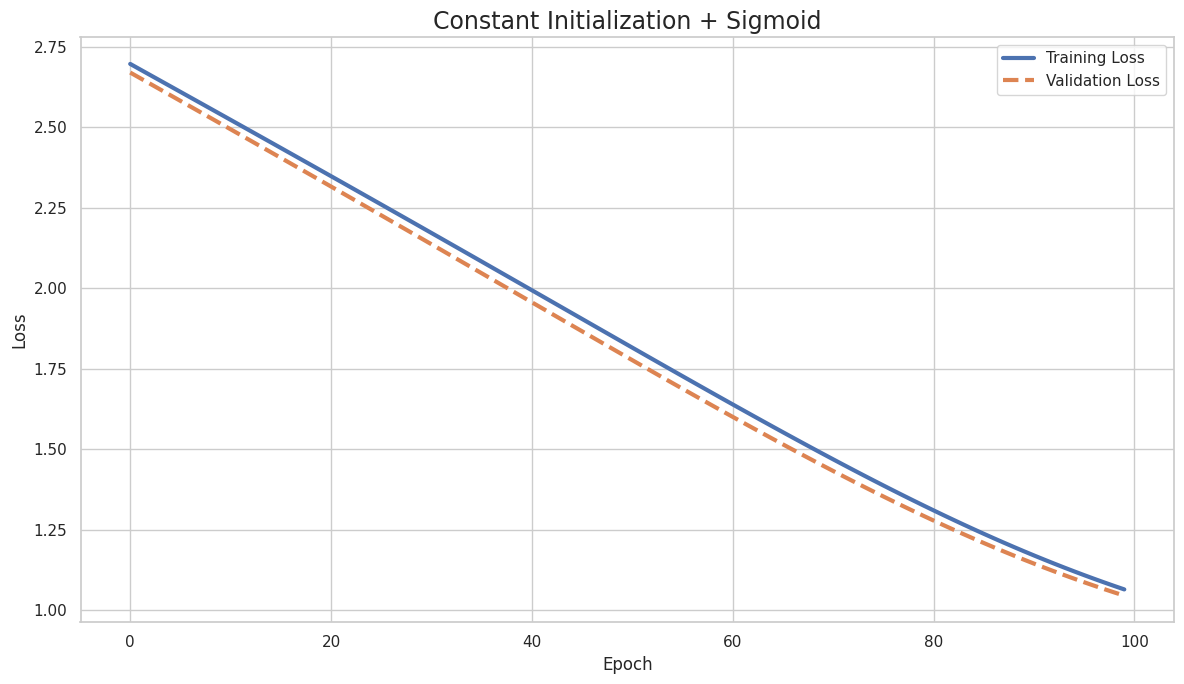

In [22]:
plt.figure(figsize=(12, 7))

plt.plot(
    constant_history.history["loss"],
    linewidth=3,
    label="Training Loss"
)

plt.plot(
    constant_history.history["val_loss"],
    linewidth=3,
    linestyle="--",
    label="Validation Loss"
)

plt.title("Constant Initialization + Sigmoid")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [23]:
small_random_initializer = keras.initializers.RandomNormal(
    mean=0.0,
    stddev=0.001
)

small_random_model = Sequential([
    Input(shape=(2,)),
    Dense(
        10,
        activation="sigmoid",
        kernel_initializer=small_random_initializer,
        bias_initializer="zeros"
    ),
    Dense(
        10,
        activation="sigmoid",
        kernel_initializer=small_random_initializer,
        bias_initializer="zeros"
    ),
    Dense(
        1,
        activation="sigmoid",
        kernel_initializer=small_random_initializer,
        bias_initializer="zeros"
    )
])

small_random_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [24]:
small_random_history = small_random_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

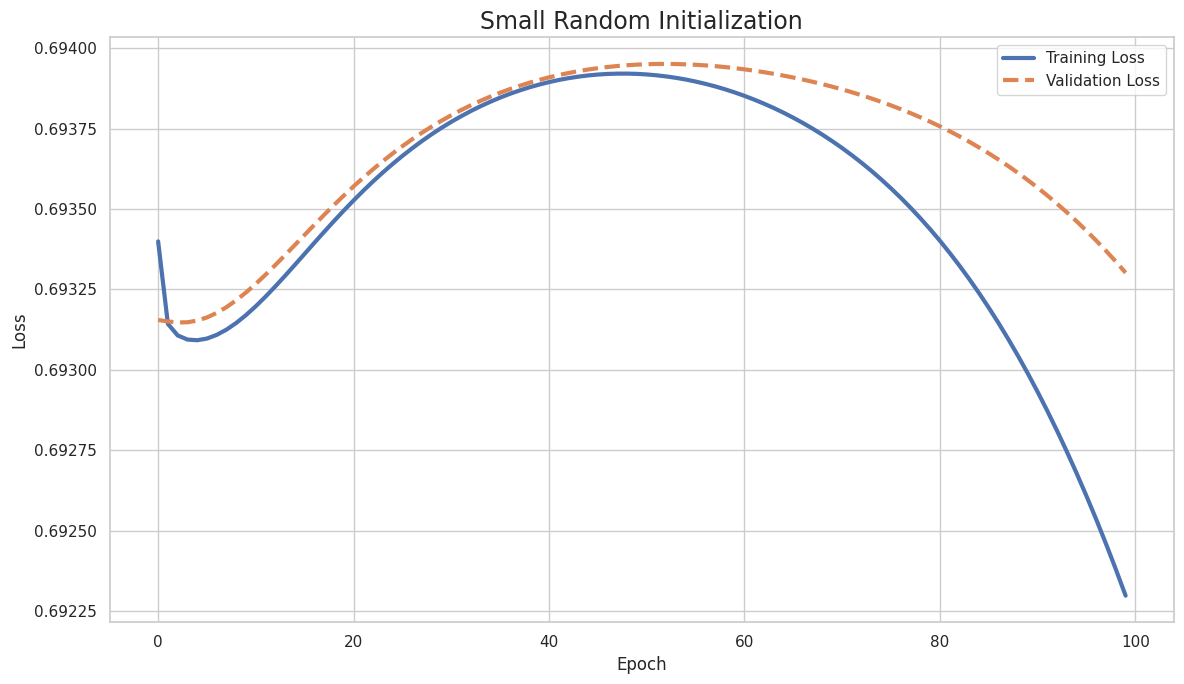

In [25]:
plt.figure(figsize=(12, 7))

plt.plot(
    small_random_history.history["loss"],
    linewidth=3,
    label="Training Loss"
)

plt.plot(
    small_random_history.history["val_loss"],
    linewidth=3,
    linestyle="--",
    label="Validation Loss"
)

plt.title("Small Random Initialization")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
large_random_initializer = keras.initializers.RandomUniform(
    minval=-5,
    maxval=5
)

large_random_model = Sequential([
    Input(shape=(2,)),
    Dense(
        10,
        activation="sigmoid",
        kernel_initializer=large_random_initializer,
        bias_initializer="zeros"
    ),
    Dense(
        10,
        activation="sigmoid",
        kernel_initializer=large_random_initializer,
        bias_initializer="zeros"
    ),
    Dense(
        1,
        activation="sigmoid",
        kernel_initializer=large_random_initializer,
        bias_initializer="zeros"
    )
])

large_random_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

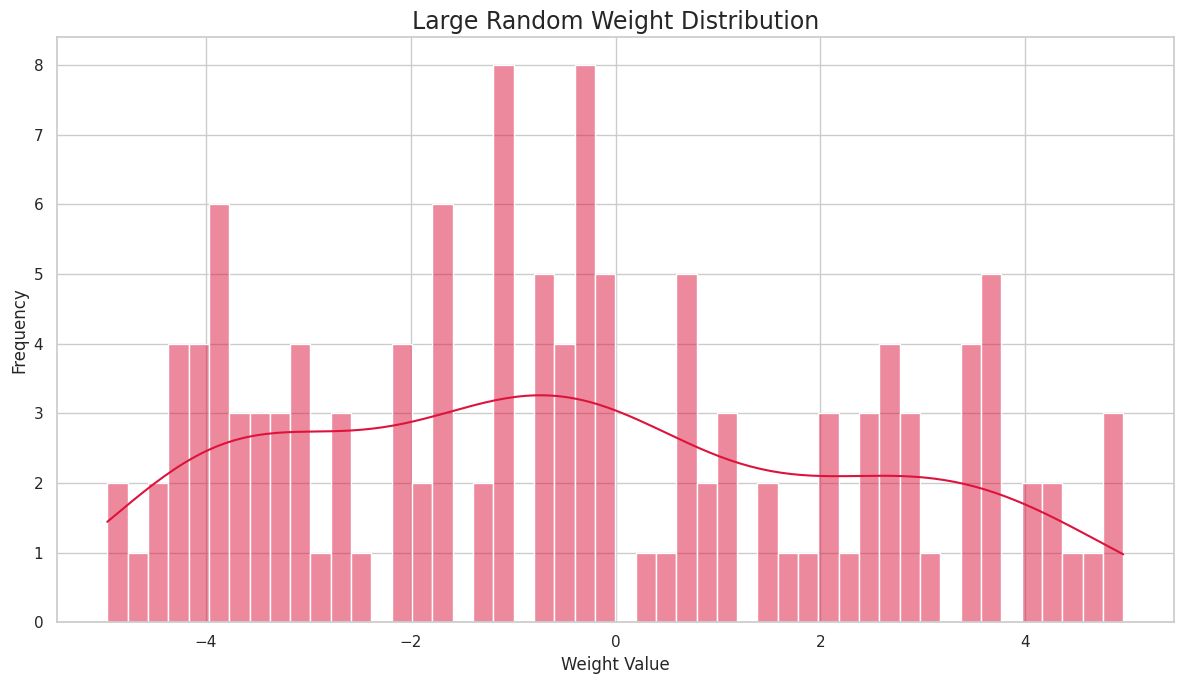

In [27]:
large_weight_values = np.concatenate([
    w.flatten()
    for w in large_random_model.get_weights()
    if w.ndim > 1
])

plt.figure(figsize=(12, 7))

sns.histplot(
    large_weight_values,
    bins=50,
    kde=True,
    color="crimson"
)

plt.title("Large Random Weight Distribution")
plt.xlabel("Weight Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [28]:
zero_sigmoid_activation_model = keras.Model(
    inputs=zero_sigmoid_model.inputs,
    outputs=[
        zero_sigmoid_model.layers[0].output,
        zero_sigmoid_model.layers[1].output
    ]
)

zero_relu_activation_model = keras.Model(
    inputs=zero_relu_model.inputs,
    outputs=[
        zero_relu_model.layers[0].output,
        zero_relu_model.layers[1].output
    ]
)

small_random_activation_model = keras.Model(
    inputs=small_random_model.inputs,
    outputs=[
        small_random_model.layers[0].output,
        small_random_model.layers[1].output
    ]
)

large_random_activation_model = keras.Model(
    inputs=large_random_model.inputs,
    outputs=[
        large_random_model.layers[0].output,
        large_random_model.layers[1].output
    ]
)

In [29]:
zero_sigmoid_activations = zero_sigmoid_activation_model.predict(
    X,
    verbose=0
)

zero_sigmoid_layer_1 = zero_sigmoid_activations[0]
zero_sigmoid_layer_2 = zero_sigmoid_activations[1]

print("Layer 1 Shape:", zero_sigmoid_layer_1.shape)
print("Layer 2 Shape:", zero_sigmoid_layer_2.shape)

Layer 1 Shape: (100, 10)
Layer 2 Shape: (100, 10)


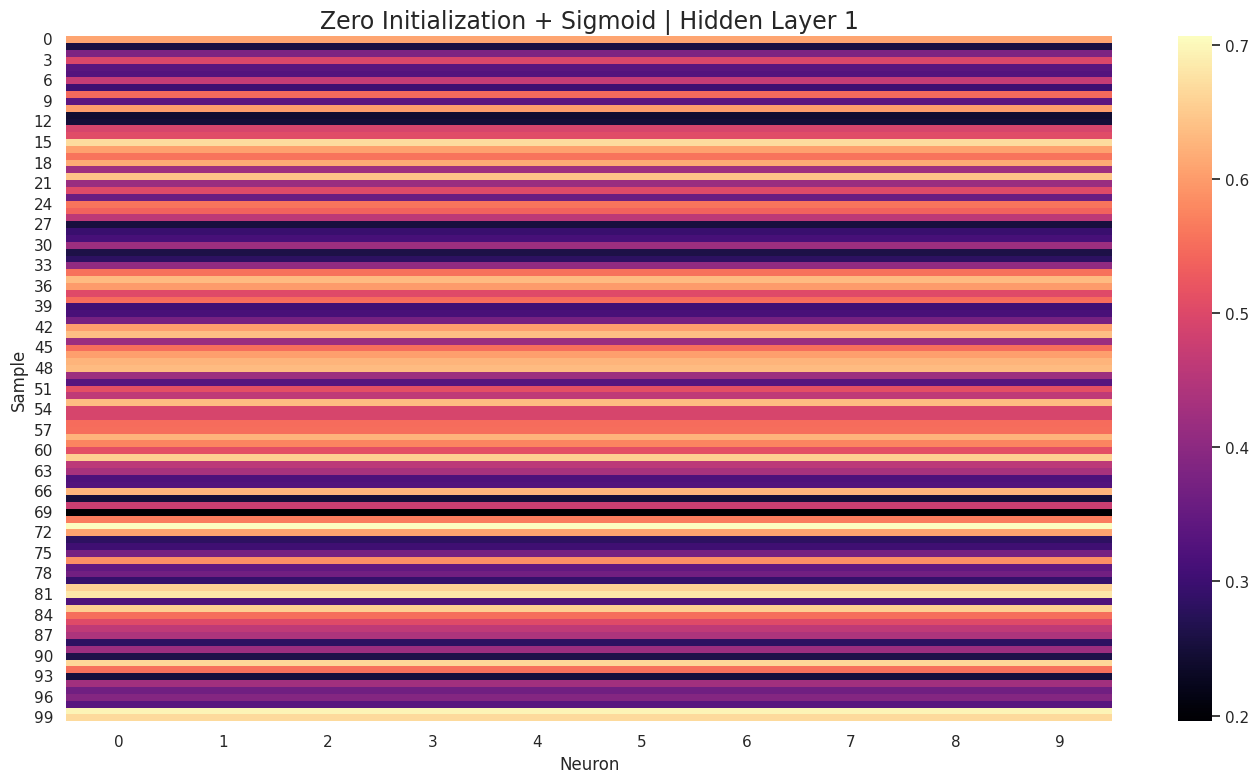

In [30]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    zero_sigmoid_layer_1[:100],
    cmap="magma",
    cbar=True
)

plt.title("Zero Initialization + Sigmoid | Hidden Layer 1")
plt.xlabel("Neuron")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

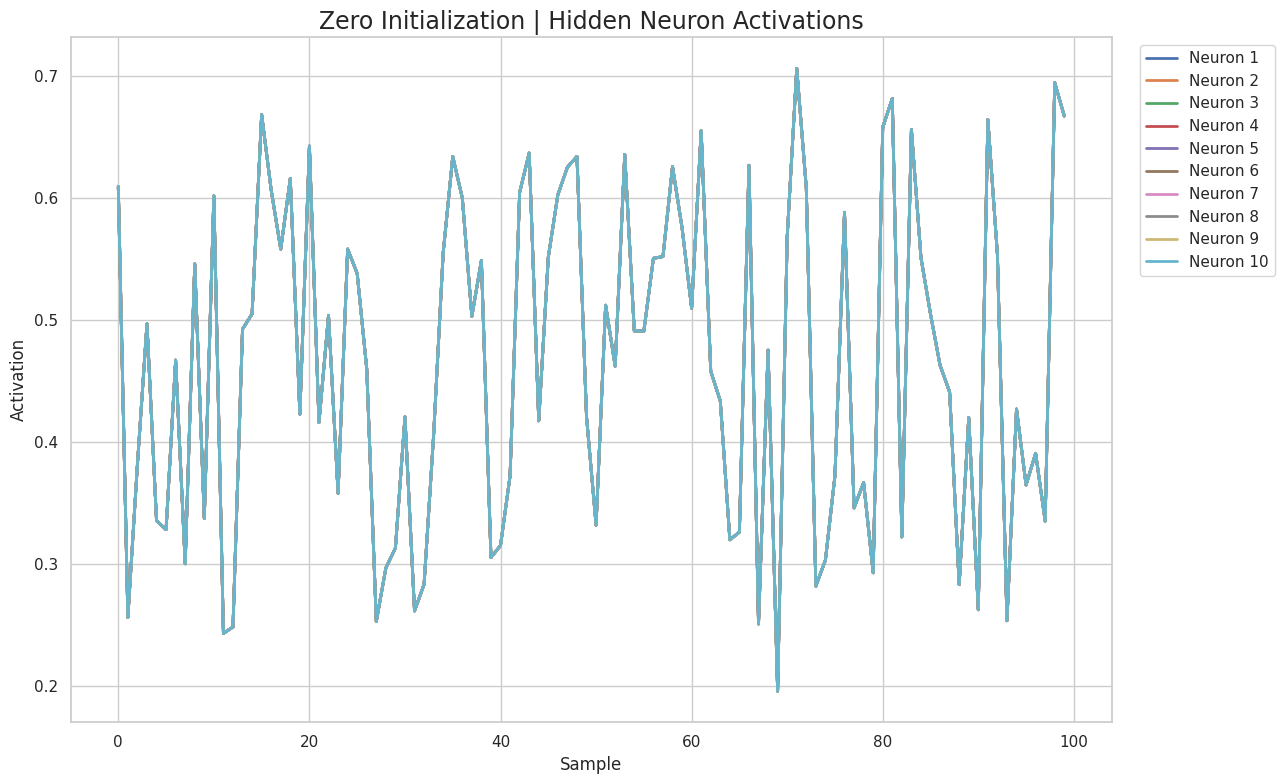

In [31]:
plt.figure(figsize=(13, 8))

for i in range(10):
    plt.plot(
        zero_sigmoid_layer_1[:100, i],
        linewidth=2,
        label=f"Neuron {i + 1}"
    )

plt.title("Zero Initialization | Hidden Neuron Activations")
plt.xlabel("Sample")
plt.ylabel("Activation")
plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

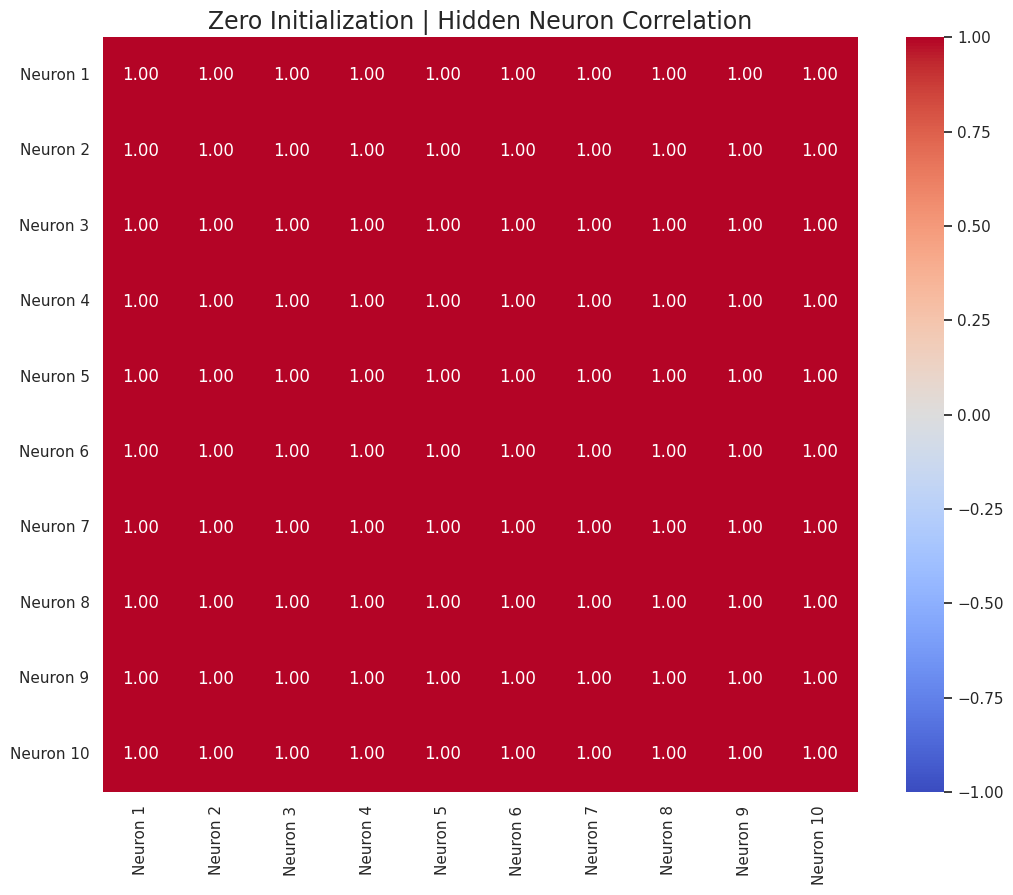

In [32]:
zero_sigmoid_neuron_df = pd.DataFrame(
    zero_sigmoid_layer_1,
    columns=[
        f"Neuron {i + 1}"
        for i in range(zero_sigmoid_layer_1.shape[1])
    ]
)

plt.figure(figsize=(11, 9))

sns.heatmap(
    zero_sigmoid_neuron_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Zero Initialization | Hidden Neuron Correlation")
plt.tight_layout()
plt.show()

In [33]:
small_random_activations = small_random_activation_model.predict(
    X,
    verbose=0
)

small_random_layer_1 = small_random_activations[0]
small_random_layer_2 = small_random_activations[1]

print("Layer 1:", small_random_layer_1.shape)
print("Layer 2:", small_random_layer_2.shape)

Layer 1: (100, 10)
Layer 2: (100, 10)


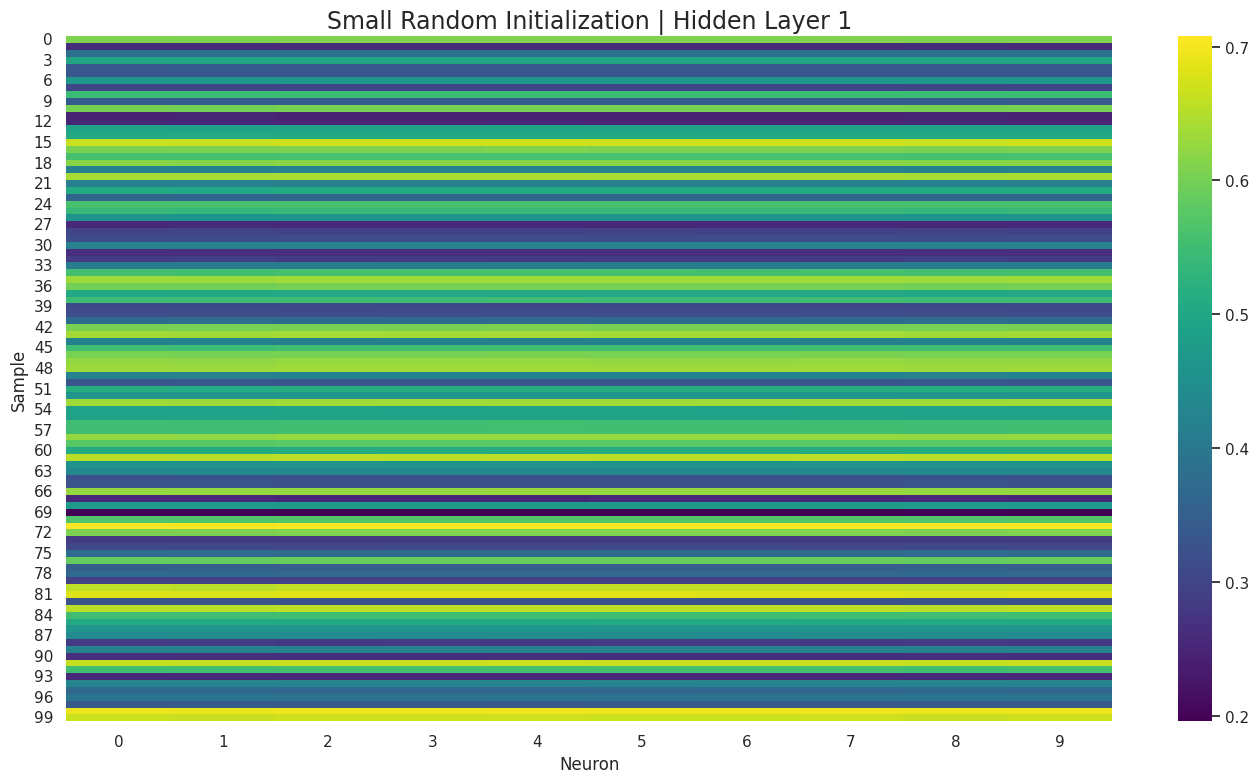

In [34]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    small_random_layer_1[:100],
    cmap="viridis",
    cbar=True
)

plt.title("Small Random Initialization | Hidden Layer 1")
plt.xlabel("Neuron")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

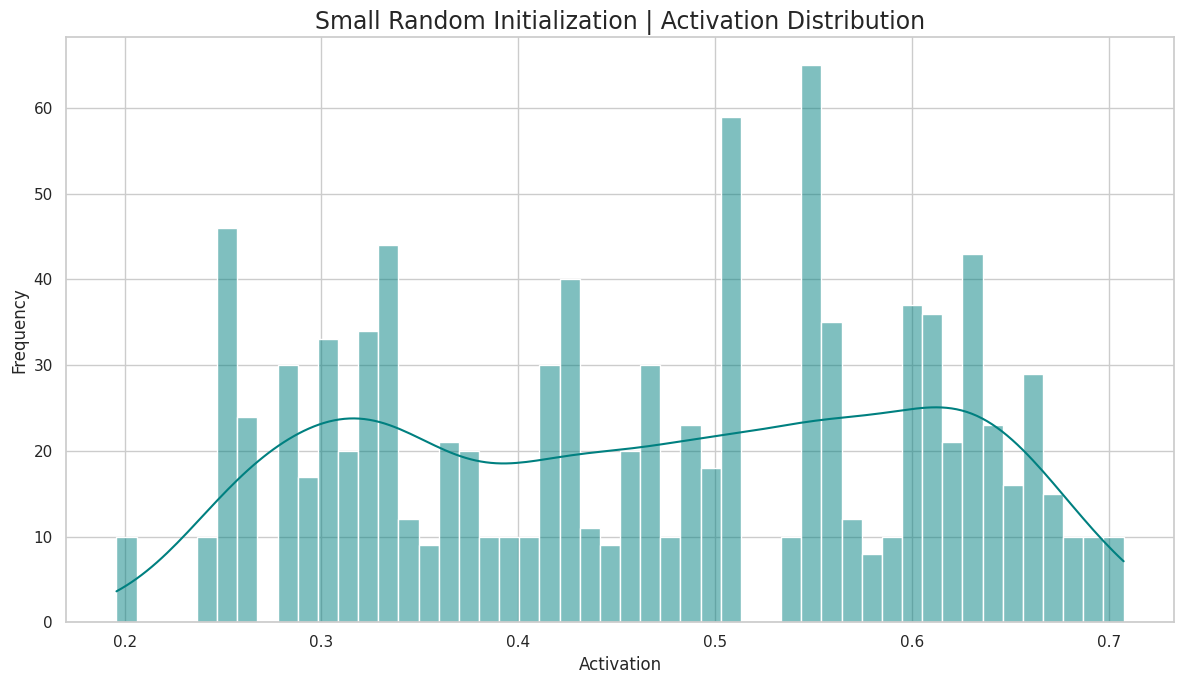

In [35]:
plt.figure(figsize=(12, 7))

sns.histplot(
    small_random_layer_1.flatten(),
    bins=50,
    kde=True,
    color="teal"
)

plt.title("Small Random Initialization | Activation Distribution")
plt.xlabel("Activation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

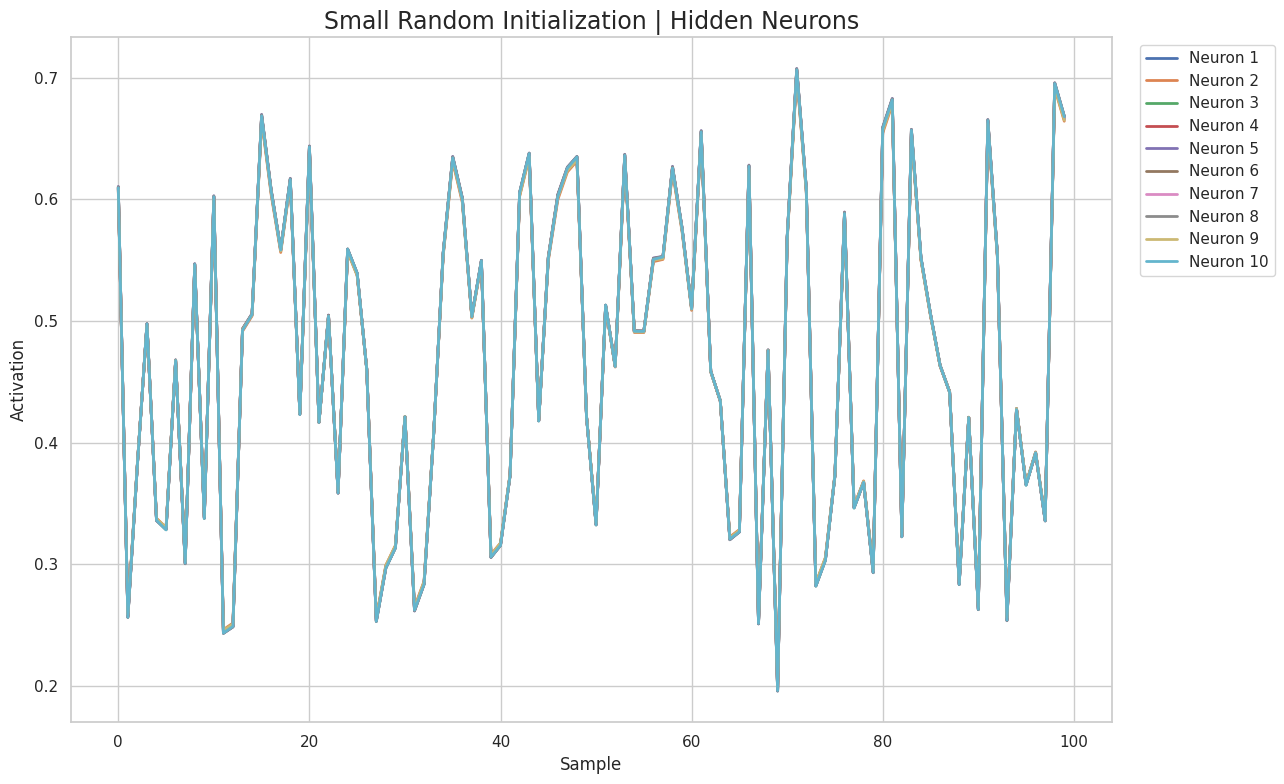

In [36]:
plt.figure(figsize=(13, 8))

for i in range(10):
    plt.plot(
        small_random_layer_1[:100, i],
        linewidth=2,
        label=f"Neuron {i + 1}"
    )

plt.title("Small Random Initialization | Hidden Neurons")
plt.xlabel("Sample")
plt.ylabel("Activation")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [37]:
large_random_activations = large_random_activation_model.predict(
    X,
    verbose=0
)

large_random_layer_1 = large_random_activations[0]
large_random_layer_2 = large_random_activations[1]

print("Layer 1:", large_random_layer_1.shape)
print("Layer 2:", large_random_layer_2.shape)

Layer 1: (100, 10)
Layer 2: (100, 10)


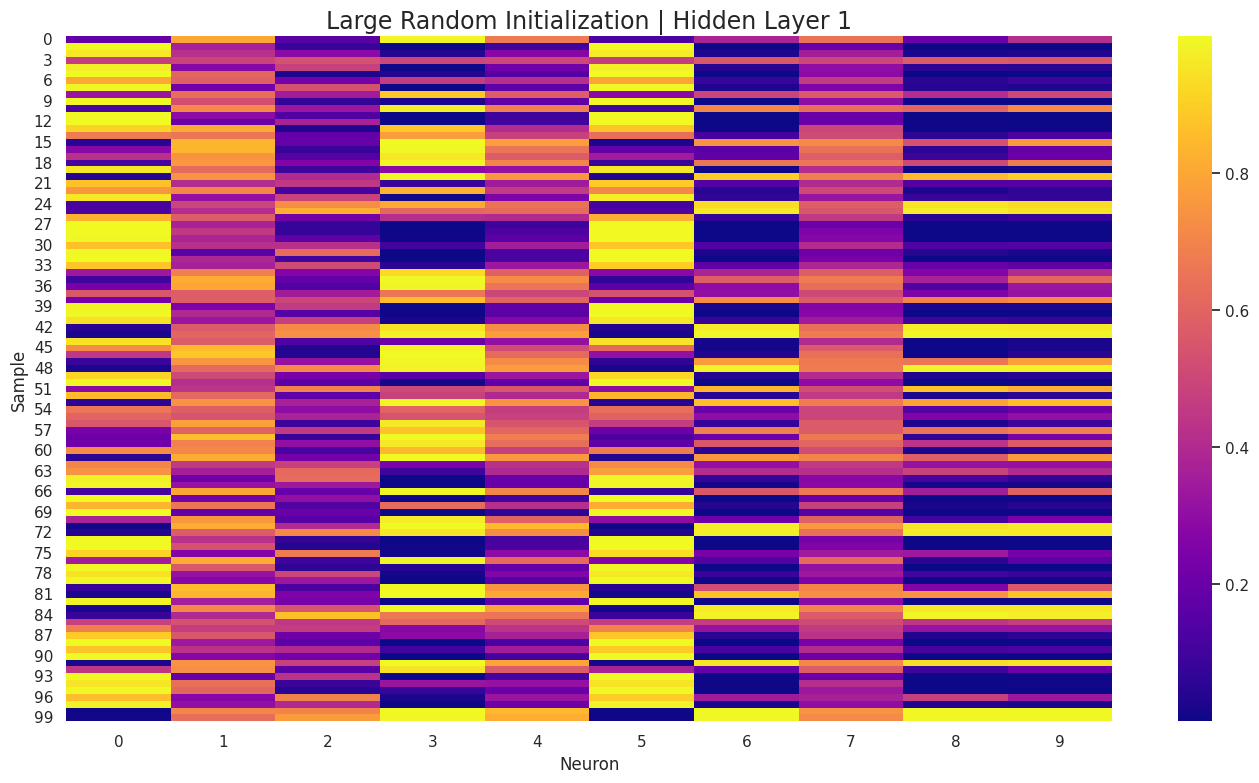

In [38]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    large_random_layer_1[:100],
    cmap="plasma",
    cbar=True
)

plt.title("Large Random Initialization | Hidden Layer 1")
plt.xlabel("Neuron")
plt.ylabel("Sample")
plt.tight_layout()
plt.show()

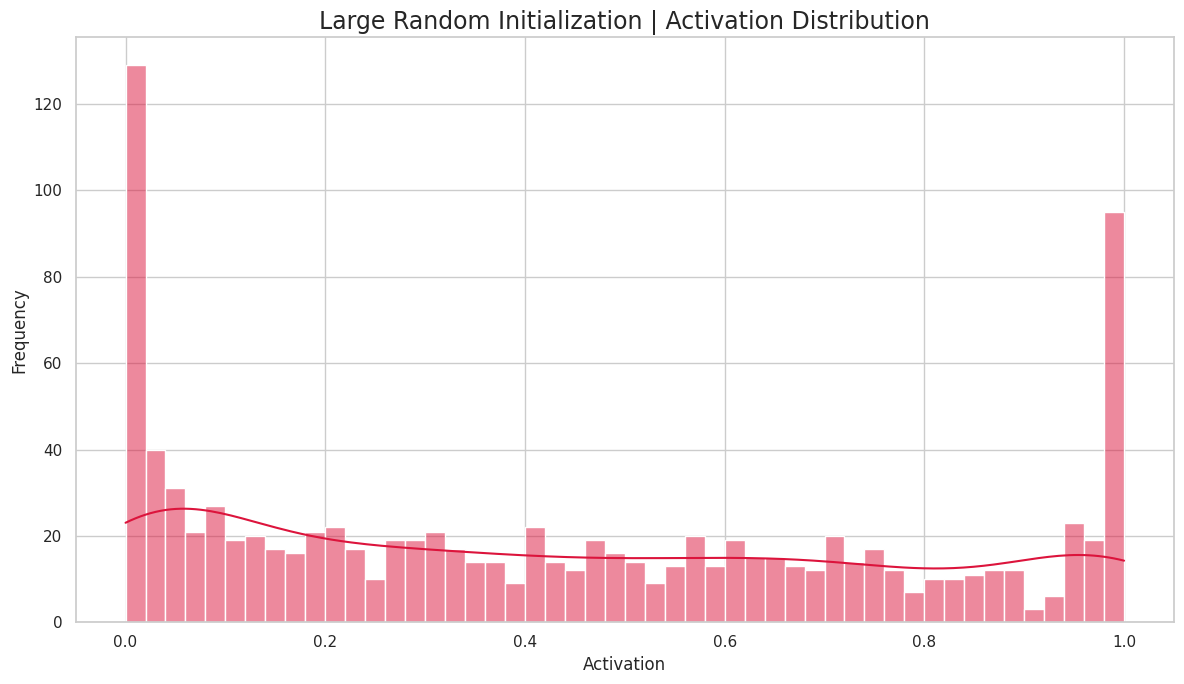

In [39]:
plt.figure(figsize=(12, 7))

sns.histplot(
    large_random_layer_1.flatten(),
    bins=50,
    kde=True,
    color="crimson"
)

plt.title("Large Random Initialization | Activation Distribution")
plt.xlabel("Activation")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [40]:
zero_weights = np.concatenate([
    w.flatten()
    for w in zero_sigmoid_model.get_weights()
    if w.ndim > 1
])

constant_weights = np.concatenate([
    w.flatten()
    for w in constant_model.get_weights()
    if w.ndim > 1
])

small_weights = np.concatenate([
    w.flatten()
    for w in small_random_model.get_weights()
    if w.ndim > 1
])

large_weights = np.concatenate([
    w.flatten()
    for w in large_random_model.get_weights()
    if w.ndim > 1
])

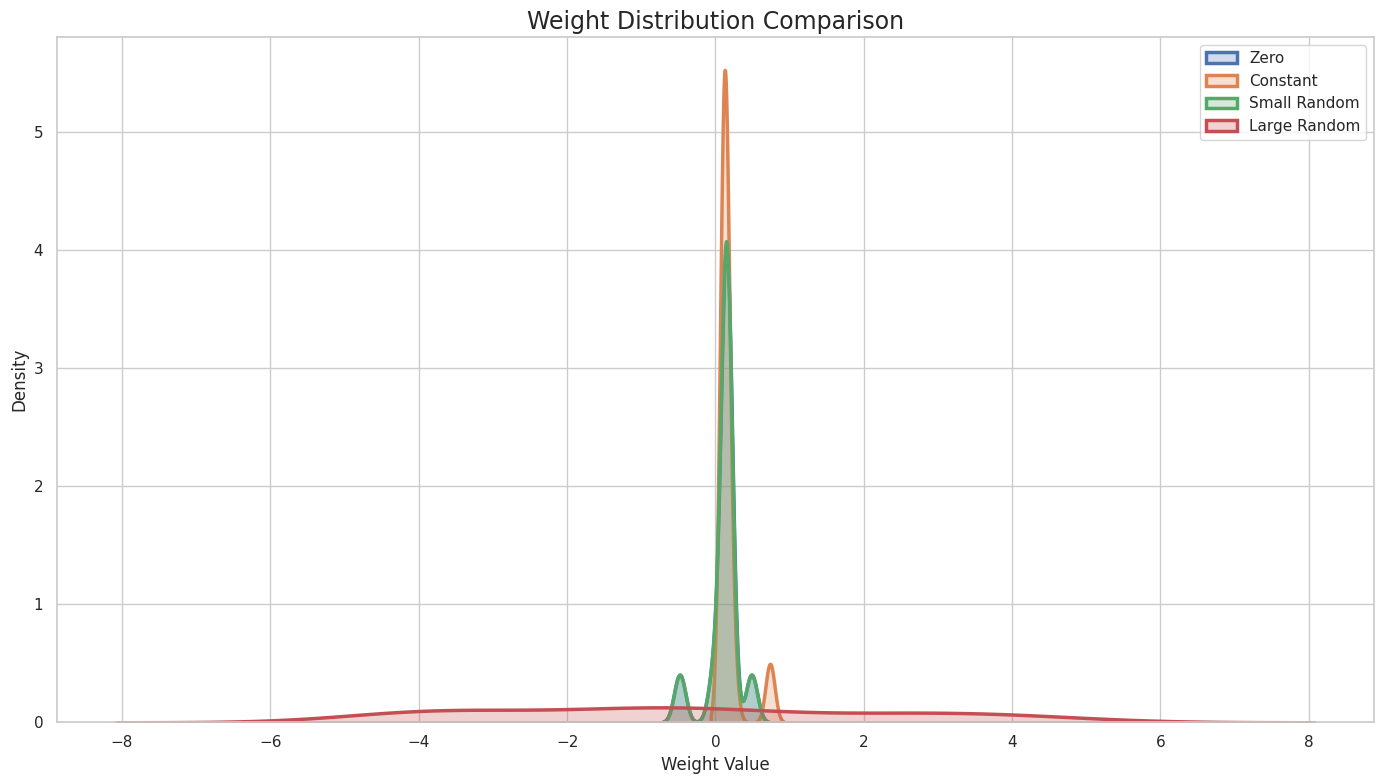

In [41]:
plt.figure(figsize=(14, 8))

sns.kdeplot(
    zero_weights,
    fill=True,
    alpha=0.25,
    linewidth=2.5,
    label="Zero"
)

sns.kdeplot(
    constant_weights,
    fill=True,
    alpha=0.25,
    linewidth=2.5,
    label="Constant"
)

sns.kdeplot(
    small_weights,
    fill=True,
    alpha=0.25,
    linewidth=2.5,
    label="Small Random"
)

sns.kdeplot(
    large_weights,
    fill=True,
    alpha=0.25,
    linewidth=2.5,
    label="Large Random"
)

plt.title("Weight Distribution Comparison")
plt.xlabel("Weight Value")
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

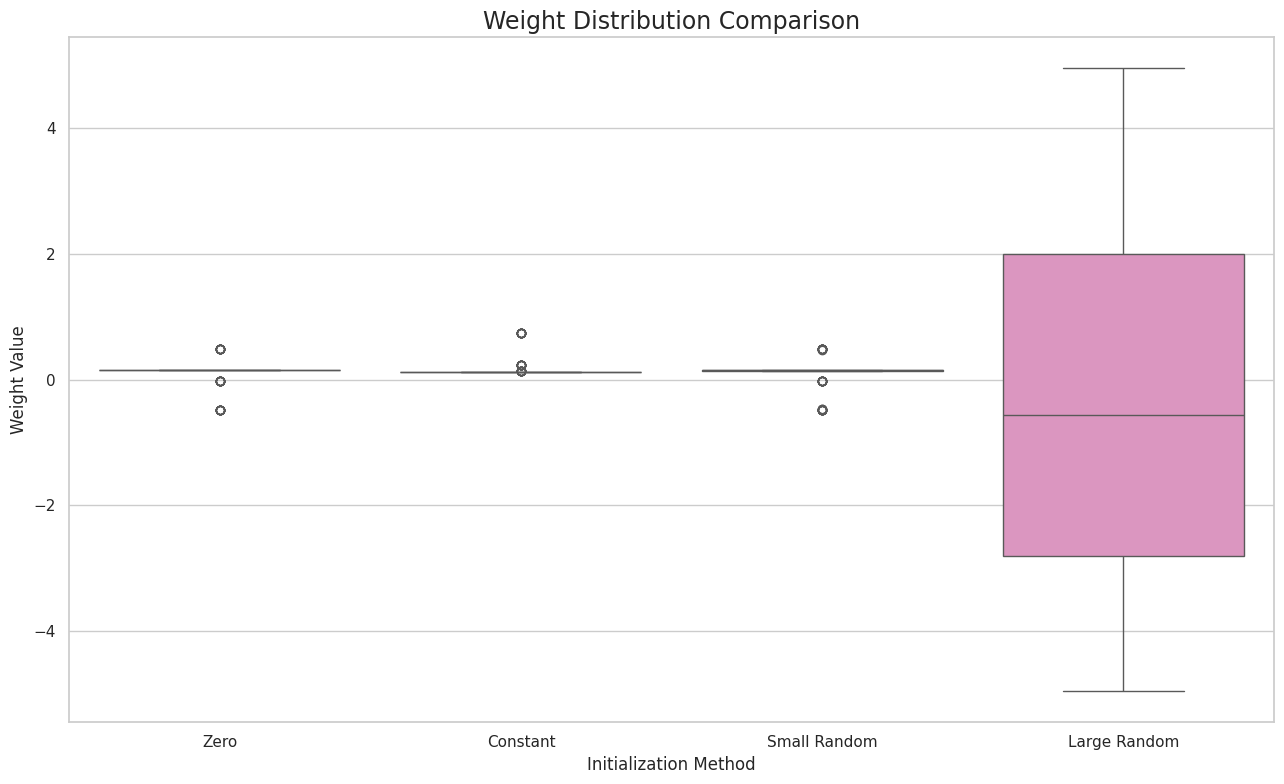

In [42]:
weight_df = pd.DataFrame({
    "Zero": pd.Series(zero_weights),
    "Constant": pd.Series(constant_weights),
    "Small Random": pd.Series(small_weights),
    "Large Random": pd.Series(large_weights)
})

plt.figure(figsize=(13, 8))

sns.boxplot(
    data=weight_df,
    palette="Set2"
)

plt.title("Weight Distribution Comparison")
plt.xlabel("Initialization Method")
plt.ylabel("Weight Value")

plt.tight_layout()
plt.show()

In [43]:
constant_history = constant_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

large_random_history = large_random_model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

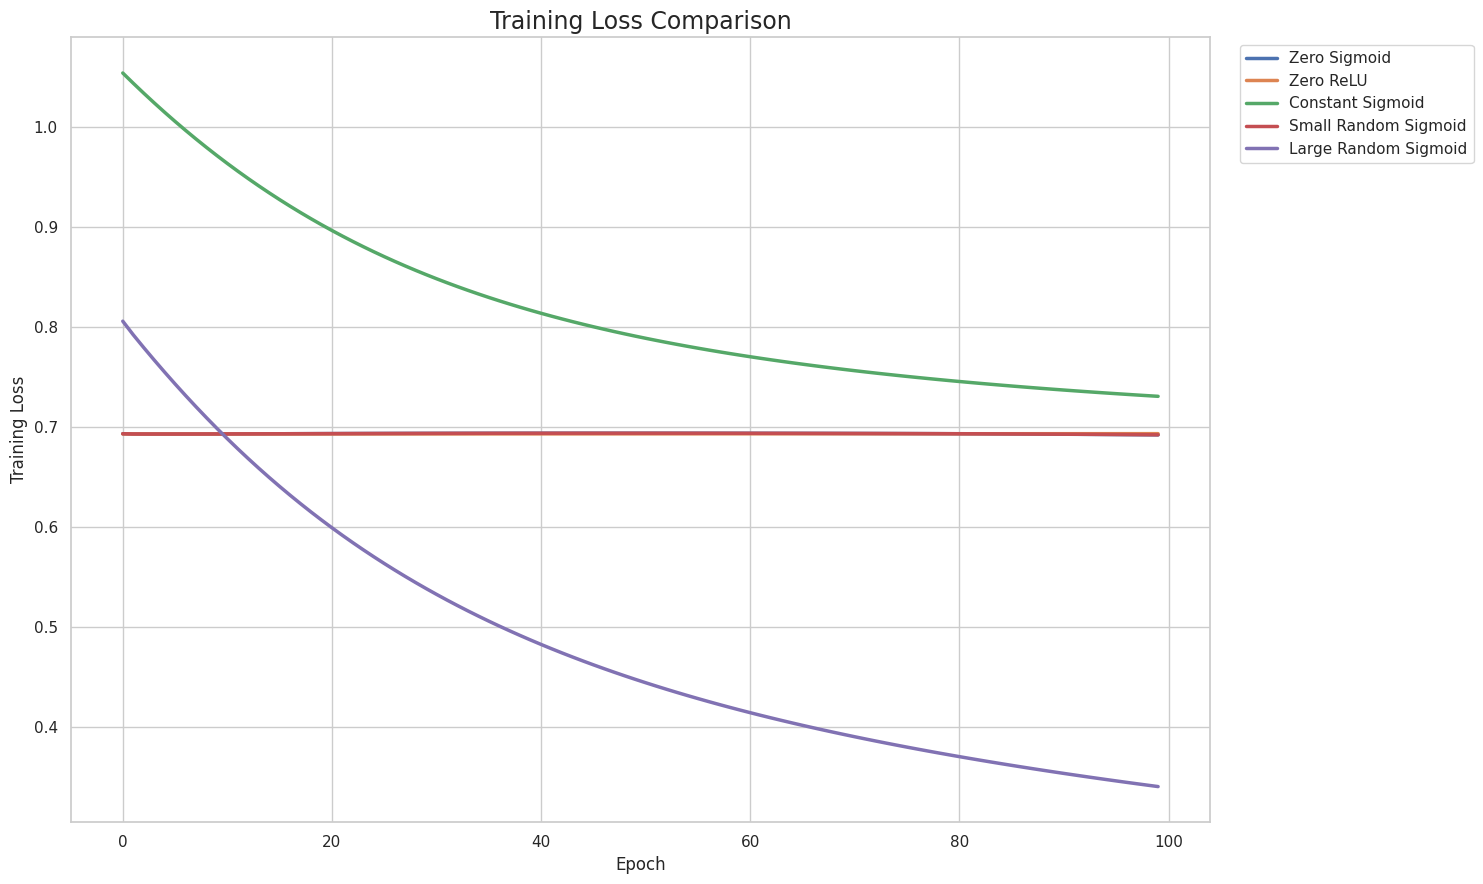

In [44]:
histories = {
    "Zero Sigmoid": zero_sigmoid_history,
    "Zero ReLU": zero_relu_history,
    "Constant Sigmoid": constant_history,
    "Small Random Sigmoid": small_random_history,
    "Large Random Sigmoid": large_random_history
}

plt.figure(figsize=(15, 9))

for name, history in histories.items():
    plt.plot(
        history.history["loss"],
        linewidth=2.5,
        label=name
    )

plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

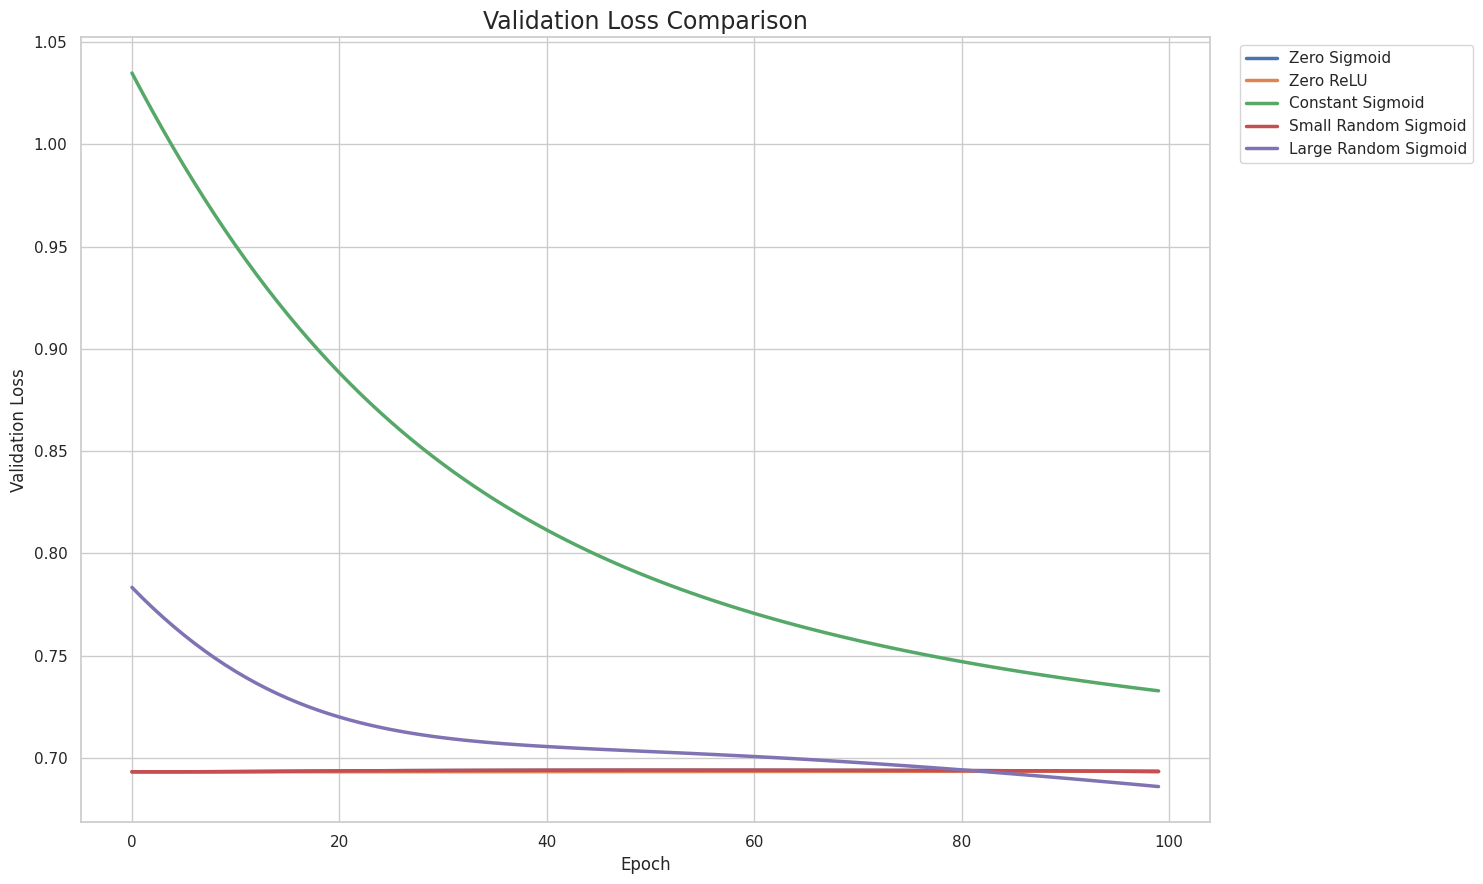

In [45]:
plt.figure(figsize=(15, 9))

for name, history in histories.items():
    plt.plot(
        history.history["val_loss"],
        linewidth=2.5,
        label=name
    )

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

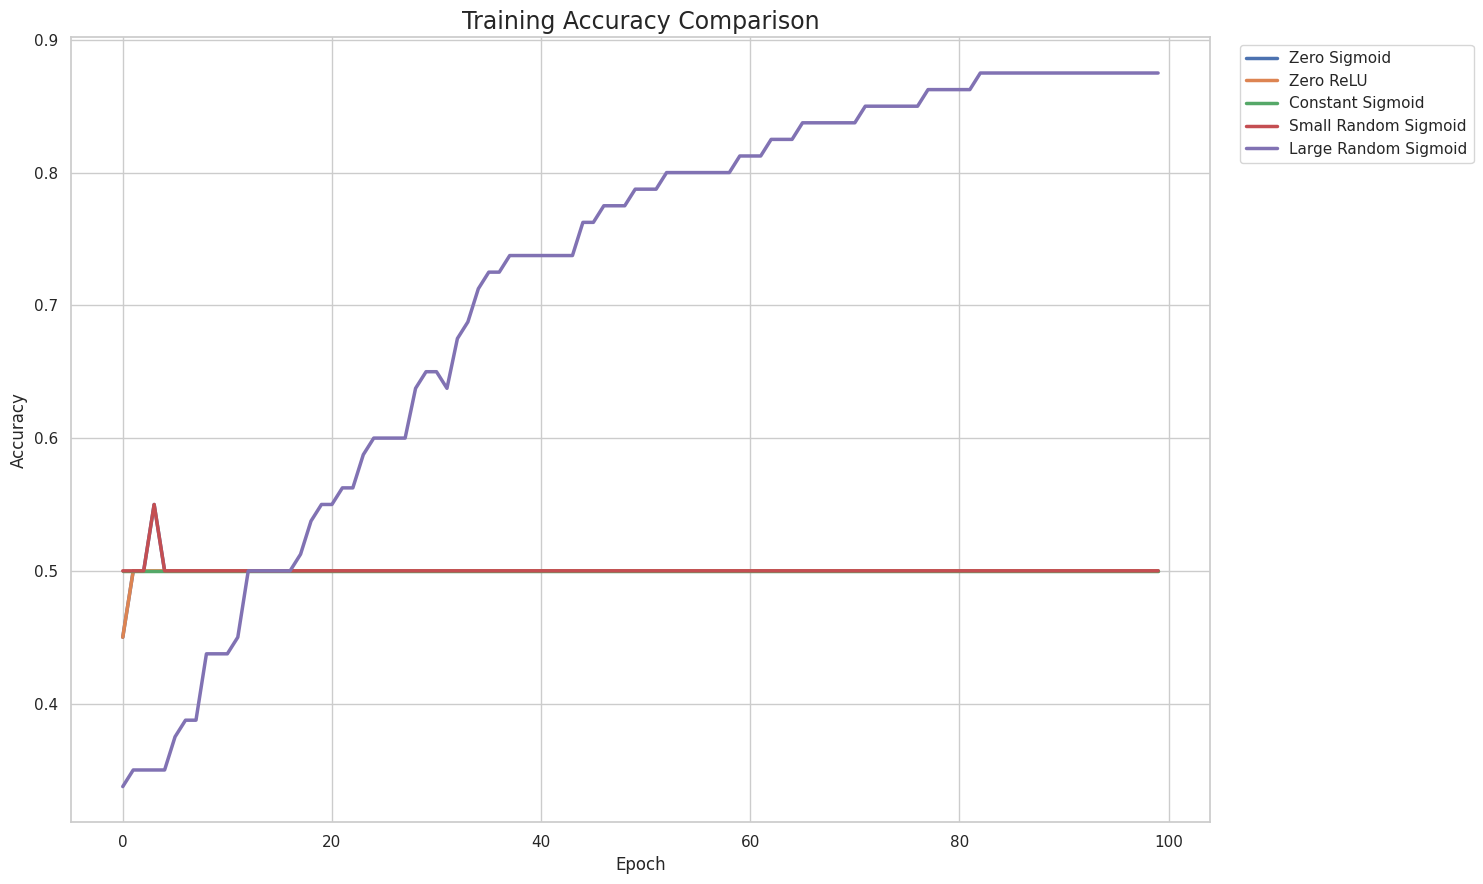

In [46]:
plt.figure(figsize=(15, 9))

for name, history in histories.items():
    plt.plot(
        history.history["accuracy"],
        linewidth=2.5,
        label=name
    )

plt.title("Training Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

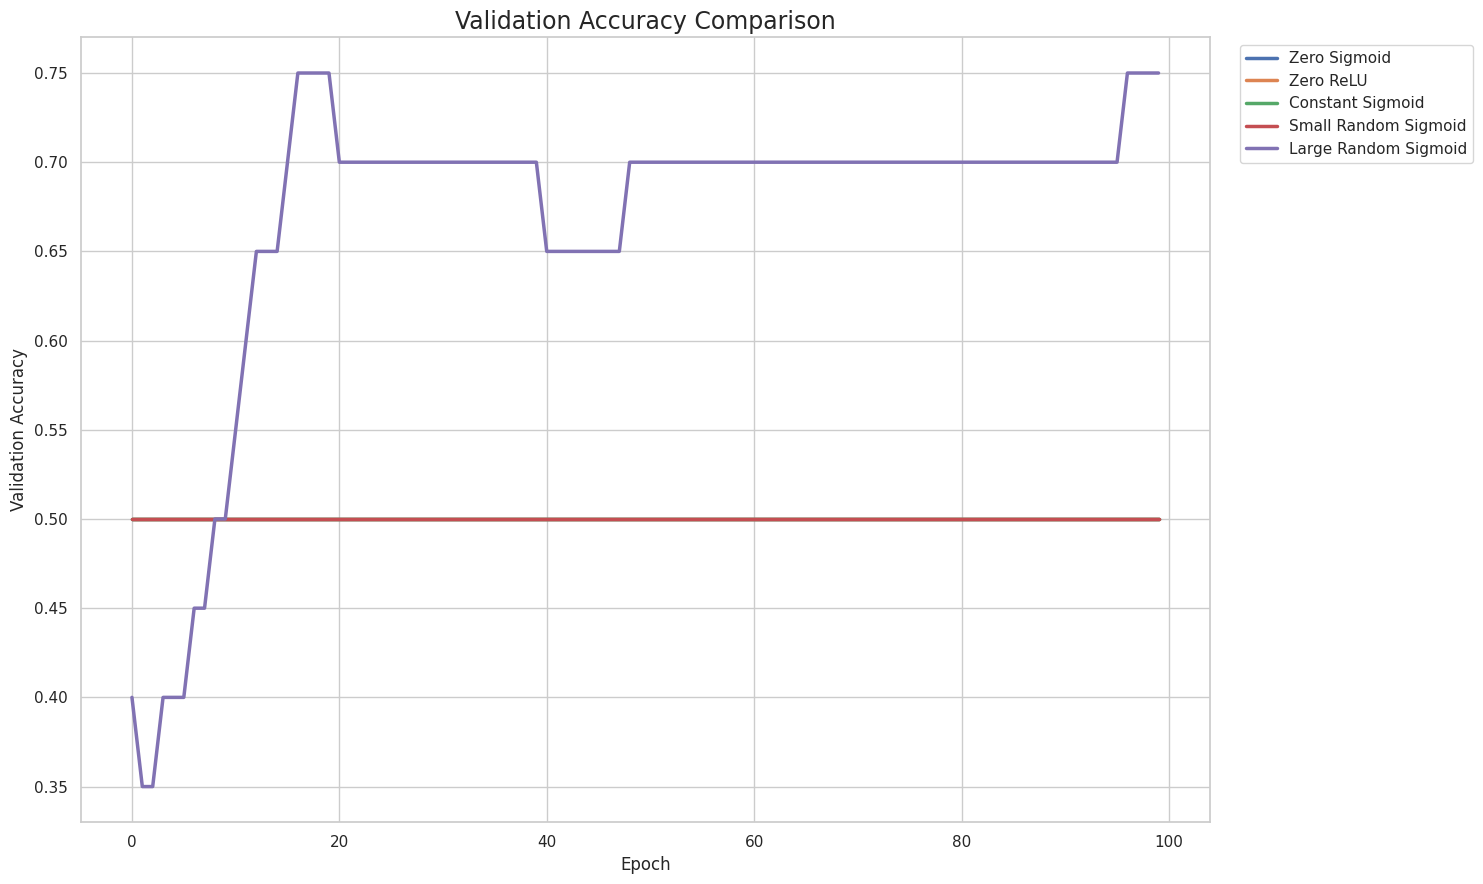

In [47]:
plt.figure(figsize=(15, 9))

for name, history in histories.items():
    plt.plot(
        history.history["val_accuracy"],
        linewidth=2.5,
        label=name
    )

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [48]:
models = {
    "Zero Sigmoid": zero_sigmoid_model,
    "Zero ReLU": zero_relu_model,
    "Constant Sigmoid": constant_model,
    "Small Random Sigmoid": small_random_model,
    "Large Random Sigmoid": large_random_model
}

results = []

for name, model in models.items():
    loss, accuracy = model.evaluate(
        X_test,
        y_test,
        verbose=0
    )

    predictions = (
        model.predict(
            X_test,
            verbose=0
        ).reshape(-1) >= 0.5
    ).astype(int)

    results.append({
        "Model": name,
        "Loss": loss,
        "Accuracy": accuracy,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "Accuracy",
        ascending=False
    )
)

,Model,Loss,Accuracy,Precision,Recall,F1 Score
4,Large Random Sigmoid,0.685931,0.75,0.857143,0.6,0.705882
0,Zero Sigmoid,0.693278,0.50,0.000000,0.0,0.000000
1,Zero ReLU,0.693467,0.50,0.000000,0.0,0.000000
2,Constant Sigmoid,0.732758,0.50,0.500000,1.0,0.666667
3,Small Random Sigmoid,0.693302,0.50,0.000000,0.0,0.000000


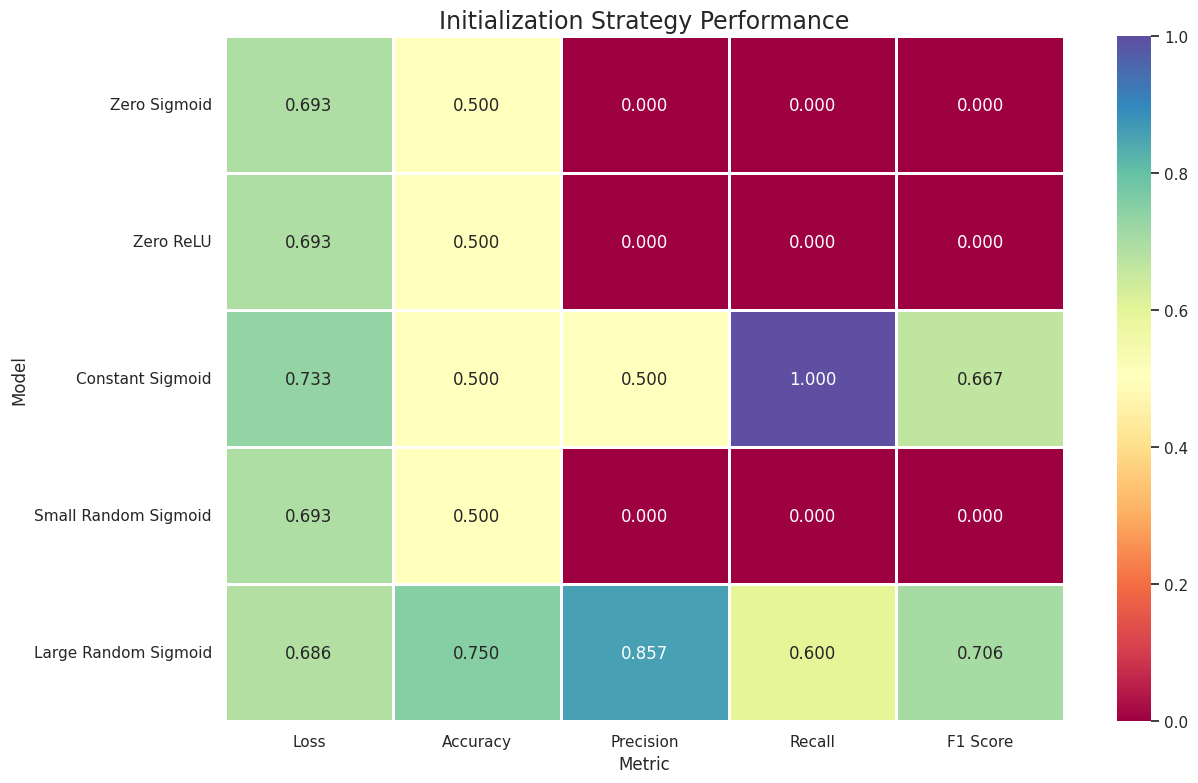

In [49]:
performance_matrix = results_df.set_index("Model")

plt.figure(figsize=(13, 8))

sns.heatmap(
    performance_matrix,
    annot=True,
    fmt=".3f",
    cmap="Spectral",
    linewidths=1,
    cbar=True
)

plt.title("Initialization Strategy Performance")
plt.xlabel("Metric")
plt.ylabel("Model")

plt.tight_layout()
plt.show()

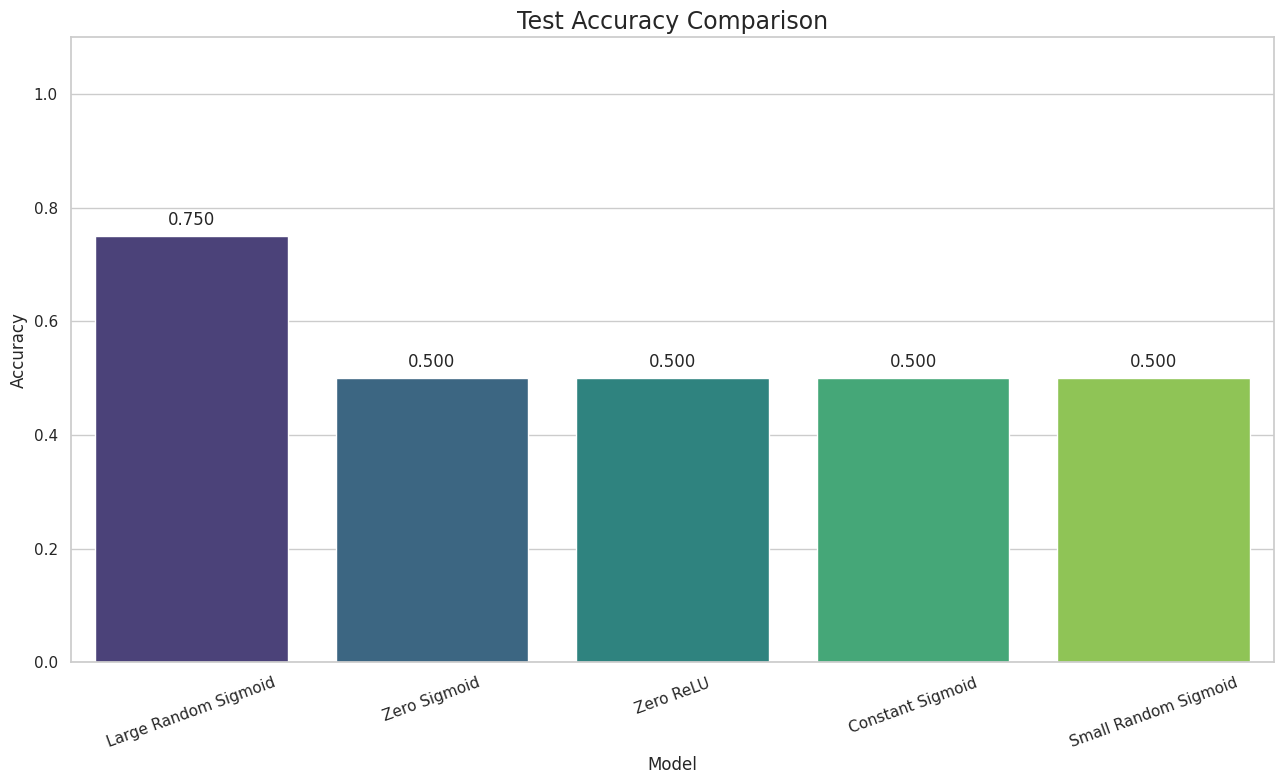

In [50]:
sorted_results = results_df.sort_values(
    "Accuracy",
    ascending=False
)

plt.figure(figsize=(13, 8))

ax = sns.barplot(
    data=sorted_results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette="viridis",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.3f",
        padding=5
    )

plt.title("Test Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

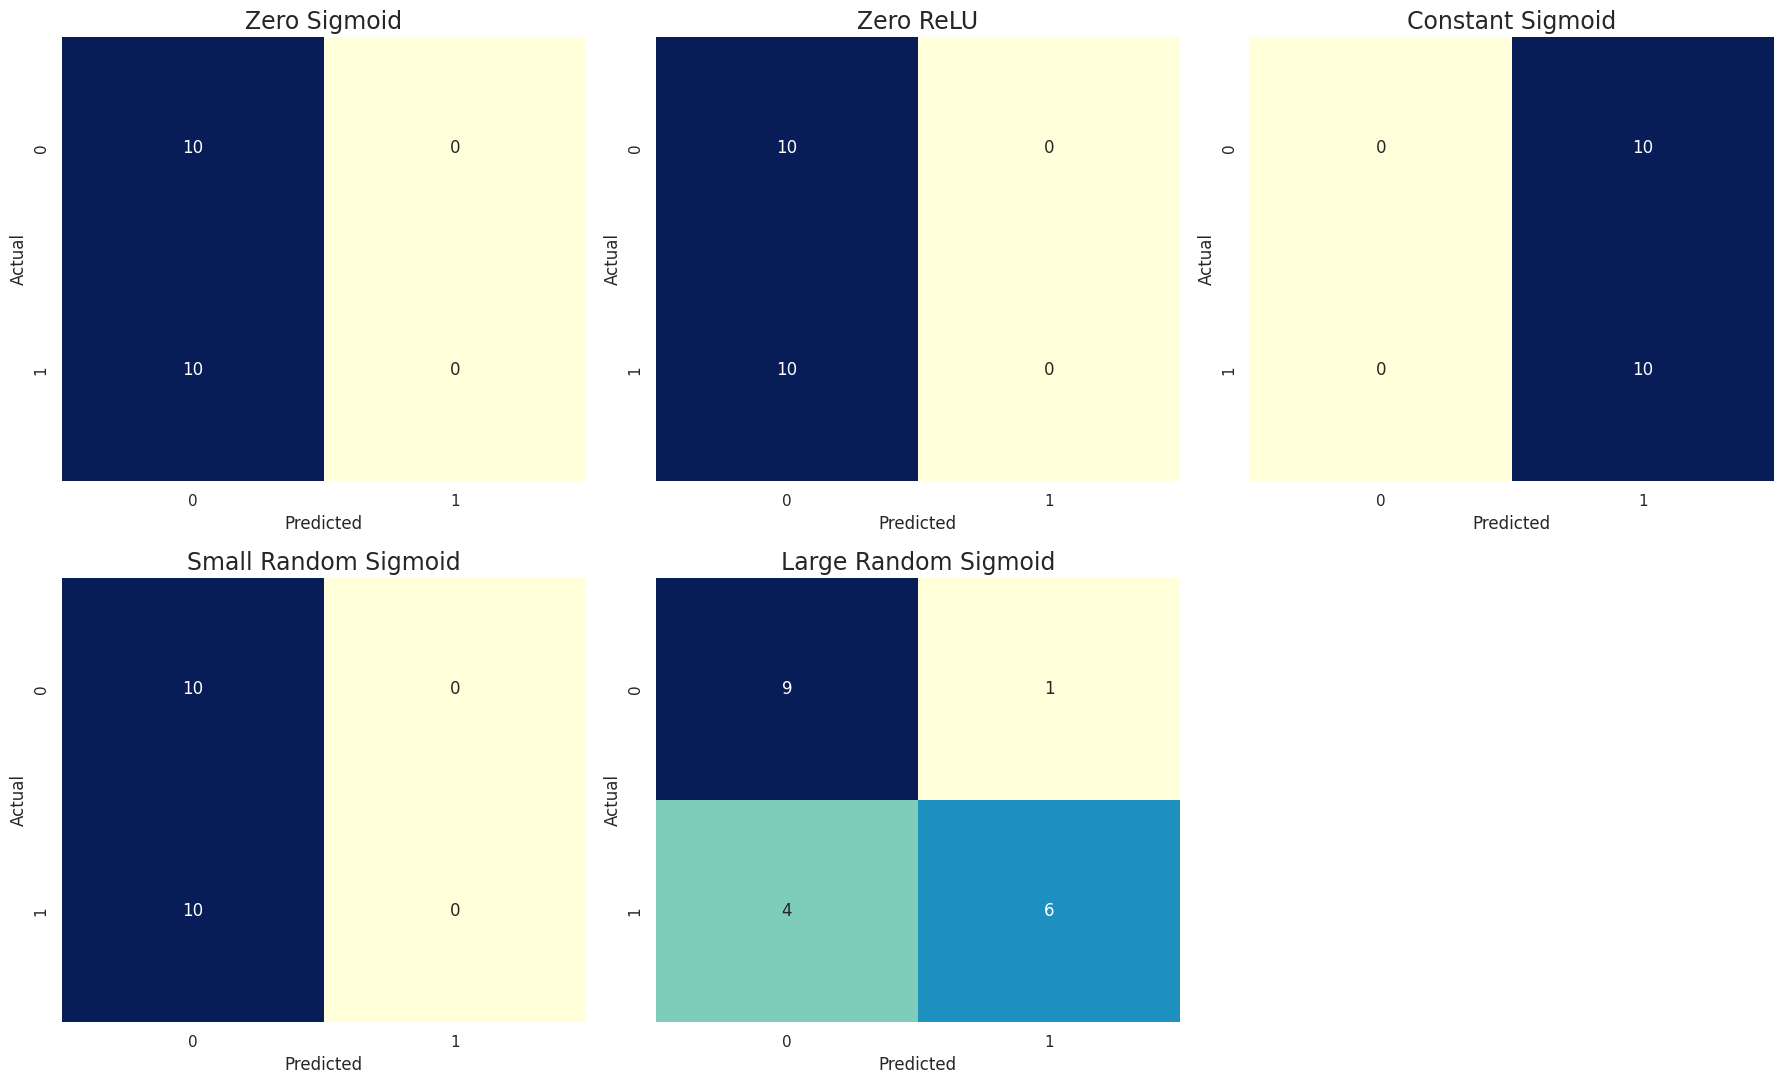

In [51]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 11)
)

axes = axes.flatten()

for index, (name, model) in enumerate(models.items()):
    predictions = (
        model.predict(
            X_test,
            verbose=0
        ).reshape(-1) >= 0.5
    ).astype(int)

    cm = confusion_matrix(
        y_test,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="YlGnBu",
        cbar=False,
        ax=axes[index]
    )

    axes[index].set_title(name)
    axes[index].set_xlabel("Predicted")
    axes[index].set_ylabel("Actual")

for index in range(len(models), len(axes)):
    axes[index].axis("off")

plt.tight_layout()
plt.show()

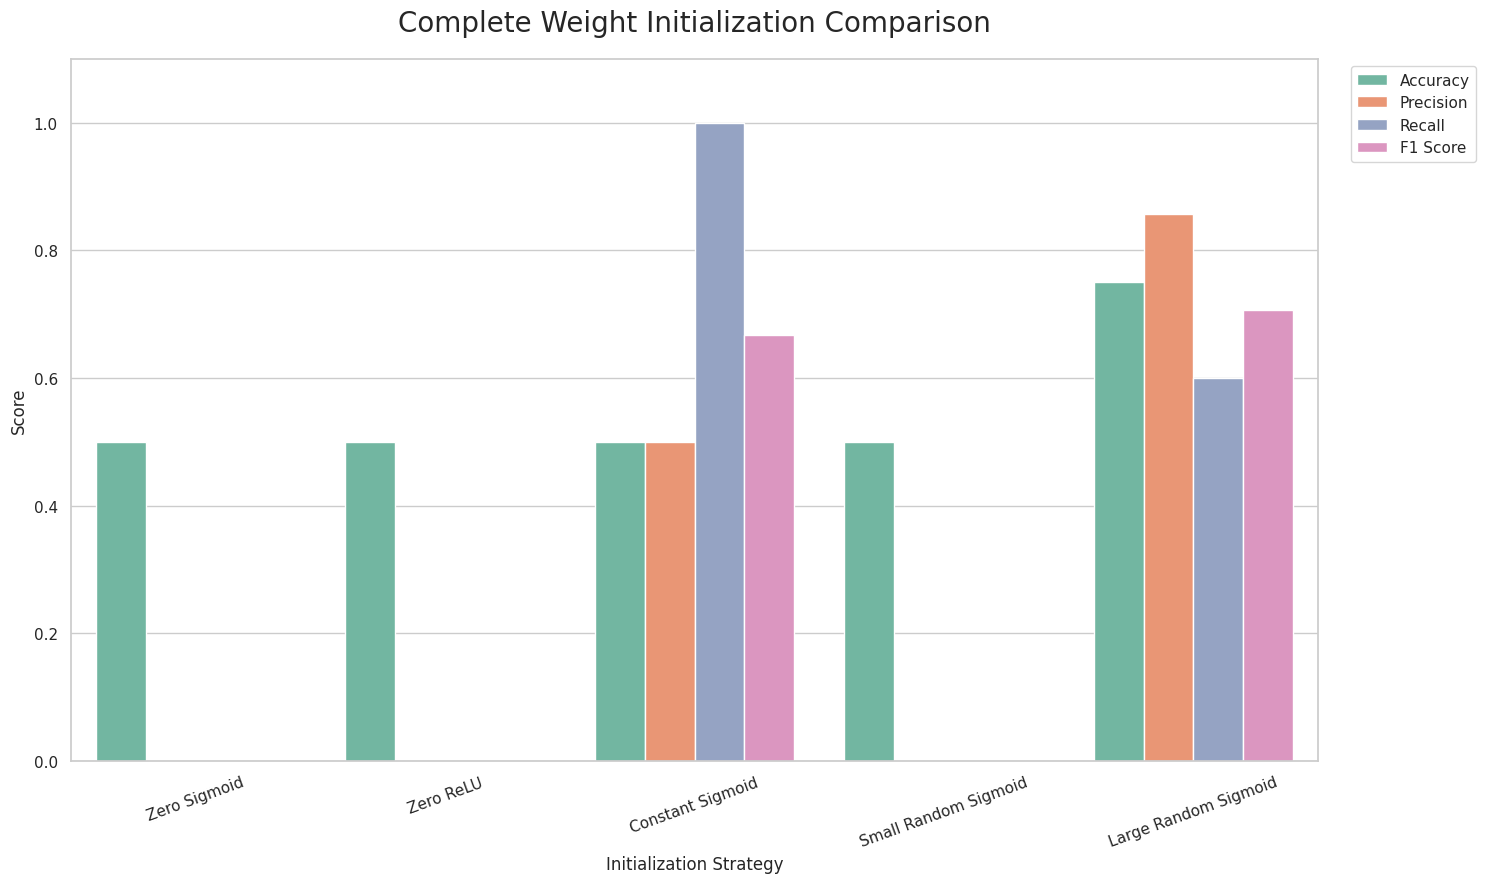

In [52]:
comparison_data = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
]

comparison_melted = comparison_data.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(15, 9))

sns.barplot(
    data=comparison_melted,
    x="Model",
    y="Score",
    hue="Metric",
    palette="Set2"
)

plt.title(
    "Complete Weight Initialization Comparison",
    fontsize=20,
    pad=20
)

plt.xlabel("Initialization Strategy")
plt.ylabel("Score")
plt.ylim(0, 1.1)
plt.xticks(rotation=20)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [53]:
best_model = results_df.loc[
    results_df["Accuracy"].idxmax()
]

print("Best Model:", best_model["Model"])
print("Accuracy:", round(best_model["Accuracy"], 4))
print("Precision:", round(best_model["Precision"], 4))
print("Recall:", round(best_model["Recall"], 4))
print("F1 Score:", round(best_model["F1 Score"], 4))

Best Model: Large Random Sigmoid
Accuracy: 0.75
Precision: 0.8571
Recall: 0.6
F1 Score: 0.7059
